![title](img/logo.png)

# Biometrics System Concepts
## Assignment 1: Evaluating performance of biometric systems
<b>Name</b>: Marty McFly |
<b>Student-nr</b>: C25 |
<b>Date</b>: June 12, 2015
---

In this assignment we focus on evaluating the performance of any biometric system in a verification and identification setting. 

Before you get started you should be able to properly distinguish verification from identification and know the corresponding validation procedures. If this is not the case for you yet, **review the lecture notes!** We will give a short recap to refresh your memory: 
* **VERIFICATION** (a.k.a. authentication): Authenticating a claimed identity (is this person who he/she claims to be?).

* **IDENTIFICATION**: Associate a particular individual with an identity (who is this unidentified individual?).

This document is structured as follows:

- [I. Reading the data](#I.-Reading-the-data)
- [II. Validation of verification system](#II.-Validation-of-verification-system)
- [III. Validation of identification system](#III.-Validation-of-identification-system)
- [IV. Assignment Instructions](#IV.-Assignment-Instructions)


Code examples will be provided below. You can and are invited to adapt these at your will (different parameter settings, different choices of alogorithmic components). The code examples in this assignment are just sekeleton code,  **adapt where needed! And try to keep things structured!** 

In [2]:
# Install and import the required python packages to run this notebook. Feel free to add more packages whenever needed.

import numpy as np
import matplotlib.pyplot as plt
# the following meta-command is required to get plots displayed in notebooks
%matplotlib inline

# package for data analysis with fast and flexible data structures
import pandas as pd

# package to show a nice graphical progress-bar for lengthy calculations
# docu and installation on https://tqdm.github.io
# if you have difficulties installing this package: 
# - make sure your jupyter lab is up to date
# - https://github.com/tqdm/tqdm/issues/394#issuecomment-384743637
# - consider just leaving it out (just remove the 'tqdm_notebook' in the code)
from tqdm.notebook import tqdm as tqdm_notebook
import pickle

<div class="alert alert-block alert-info">
<b>Tip:</b> 
Many operations have already been implemented in <a href="https://docs.scipy.org/doc/numpy/index.html">SciPy</a>, feel free to use them or any other unless explicitely stated not to in the assignment.</div>

## I. Reading the data
In this assignment we focus on the validation of a pre-exising biometric system. We will make use of synthetic similarity scores of four different biometric systems. This bypasses all steps of preprocessing, feature extraction and matching and allows us to concentrate on the score evaluation procedures. The scores are the result of comparing an enrolled user's image with the score of the same (genuine scores) or another user (impostor scores). The data can be found in the .csv files in the `./data/` subfolder. 

In this code example we will compare the performance of four biometric systems. These systems are referred to as `system1`, `system2`, `system3` and `system4` respectively in both code and text. 

<div class="alert alert-block alert-info">
<b>Tip:</b> 
For each question, make sure to <b> compare the results for the different systems</b>!!! Mention which system performs the best/worst and why.</div>

In [33]:
### 1.1. Loading the similarity matrix and reading the genuine and impostor scores
We provide you with the code to read the scores from the files (normally you can leave this code as-is).

The code consits of 2 steps that are executed for all the systems: 
1. Scores are converted to similarity matrices. To simplify the task we have provided you with the similarity matrices. You need to load the similarity matrices with the genuine scores on the diagonal and the impostor scores on the off-diagonal elements.  
2. Convert the original scores to a linear list of scores with associated labels of genuine or impostor (simplifies use of [scikit-learn](https://scikit-learn.org/stable/index.html))



SyntaxError: invalid syntax (3465119114.py, line 2)

In [3]:
# STEP 1: loading the similarity matrices for the four systems
with open('./data/system1_similarity_matrix.csv','rb') as f:
    system1_similarity_matrix = pickle.load(f)
with open('./data/system2_similarity_matrix.csv','rb') as f:
    system2_similarity_matrix = pickle.load(f)
with open('./data/system3_similarity_matrix.csv','rb') as f:
    system3_similarity_matrix = pickle.load(f)
with open('./data/system4_similarity_matrix.csv','rb') as f:
    system4_similarity_matrix = pickle.load(f)
print(type(system1_similarity_matrix))
print(system1_similarity_matrix)

<class 'numpy.ndarray'>
[[ 6.48730361  0.69352768 -3.86501703 ...  2.12183612 -0.84331811
   2.29475023]
 [ 3.77365119  5.81647308  1.97903324 ... -0.54378096 -0.24531316
   0.69868077]
 [-1.80004577 -1.60213216  5.84154847 ... -0.58968609  0.7481939
  -0.9206928 ]
 ...
 [ 0.09193256 -0.16410043  0.93337656 ...  5.97911264  3.54499178
   1.48657273]
 [ 2.65662266 -1.28256359  2.09351615 ... -0.87710247  6.10616113
   0.65302102]
 [ 3.19788089  1.00973575  4.36628529 ...  3.37207976  1.62679603
   5.9439135 ]]


In [13]:
# STEP 2: convert to genuine and impostor scores, the *_genuine_id provides a mask for the genuine scores
def sim2scores(similarity_matrix):
    # use .values to access as numpy array
    np_similarity_matrix = similarity_matrix

    # grab elements on the diagonal
    genuine_scores = np.diag(np_similarity_matrix)

    # mask elements that are on the diagonal, retain non-diagonal elements
    imposter_scores =  np_similarity_matrix[~np.eye(np_similarity_matrix.shape[0],dtype=bool)]

    # store in one single list of scores as required for the classification validation procedures
    scores = np.append(np.array(genuine_scores), np.array(imposter_scores))

    # normalize to [0,1] range, 0 corresponding to minimal similarity
    scores = (scores - scores.min())/(scores.max()-scores.min())

    ## add the genuine and imposter labels

    # tag genuine combinations as label 1 and imposter combinations as 0

    genuine_id = np.zeros_like(scores)
    genuine_id[0:genuine_scores.shape[0]] = 1

    return(genuine_id, scores)


system1_genuine_id, system1_scores = sim2scores(system1_similarity_matrix)
system2_genuine_id, system2_scores = sim2scores(system2_similarity_matrix)
system3_genuine_id, system3_scores = sim2scores(system3_similarity_matrix)
system4_genuine_id, system4_scores = sim2scores(system4_similarity_matrix)


1000000


<div class="alert alert-block alert-info">
<b>Tip:</b> 
In this assignment we focus only on evaluating biometric systems. It is in your best interest to write your code such that it can easily be reused in the upcoming assignments, where you will have to develop entire biometric system pipelines.</div>

## II. Validation of verification system

[1]: <https://link.springer.com/book/10.1007/978-0-387-77326-1> ('Introduction to Biometrics' by AK Jain et al)
[2]: <https://machinelearningmastery.com/roc-curves-and-precision-recall-curves-for-classification-in-python/> (How and When to Use ROC Curves and Precision-Recall Curves for Classification in Python)

The performance of a verification scenario can be expressed in a number of ways (see [Jain et al.][1] section 1.4.1.1 for more information). In essence one has a binary classification problem: is it the claimed identity or not? 

We denote our classes as:
<ol start="0">
  <li>Impostor (False),</li>
  <li>Genuine (True).</li>
</ol>

Furthermore, we represent the set of scores as s, the imposter event as $I$ and a genuine event as $G$.

### 1. Evaluation using FMR, FRR, ROC and Precision/Recall curves

[1]: <https://link.springer.com/book/10.1007/978-0-387-77326-1> ('Introduction to Biometrics' by AK Jain et al)
[2]: <https://machinelearningmastery.com/roc-curves-and-precision-recall-curves-for-classification-in-python/> (How and When to Use ROC Curves and Precision-Recall Curves for Classification in Python)



#### 1.1 Genuine and impostor score distributions
Given the genuine and impostor scores (from section I), we can plot the imposter $p(s | I)$ and genuine $p(s | G)$ distribution to gain some first insights in the system. The result should look something like this:

<p align="center">
    <img src="img/ScoreDistributions.png" width="250" height="auto"/>
</p>


<div class="alert alert-block alert-success">
<b>Q1: </b> Score distributions
<ul>
  <li>Plot the genuine and impostor score distributions in a single plot for the four systems.</li>
  <li>Do you need to normalize the distributions? Why (not)?</li>
  <li>Describe qualitatively this combined plot. Which system performs the best based on this plot?</li>
  <li>Which system corresponds to which of the following descriptions?</li>
  <ol type = 'A'>
    <li> small inter-user distance, small intra-user variation </li>
    <li> small inter-user similarity, small intra-user variation </li>
    <li> large inter-user similarity, large intra-user variation </li>
    <li> large inter-user distance, large intra-user variation </li>
  </ol>
</ul>  
</div>

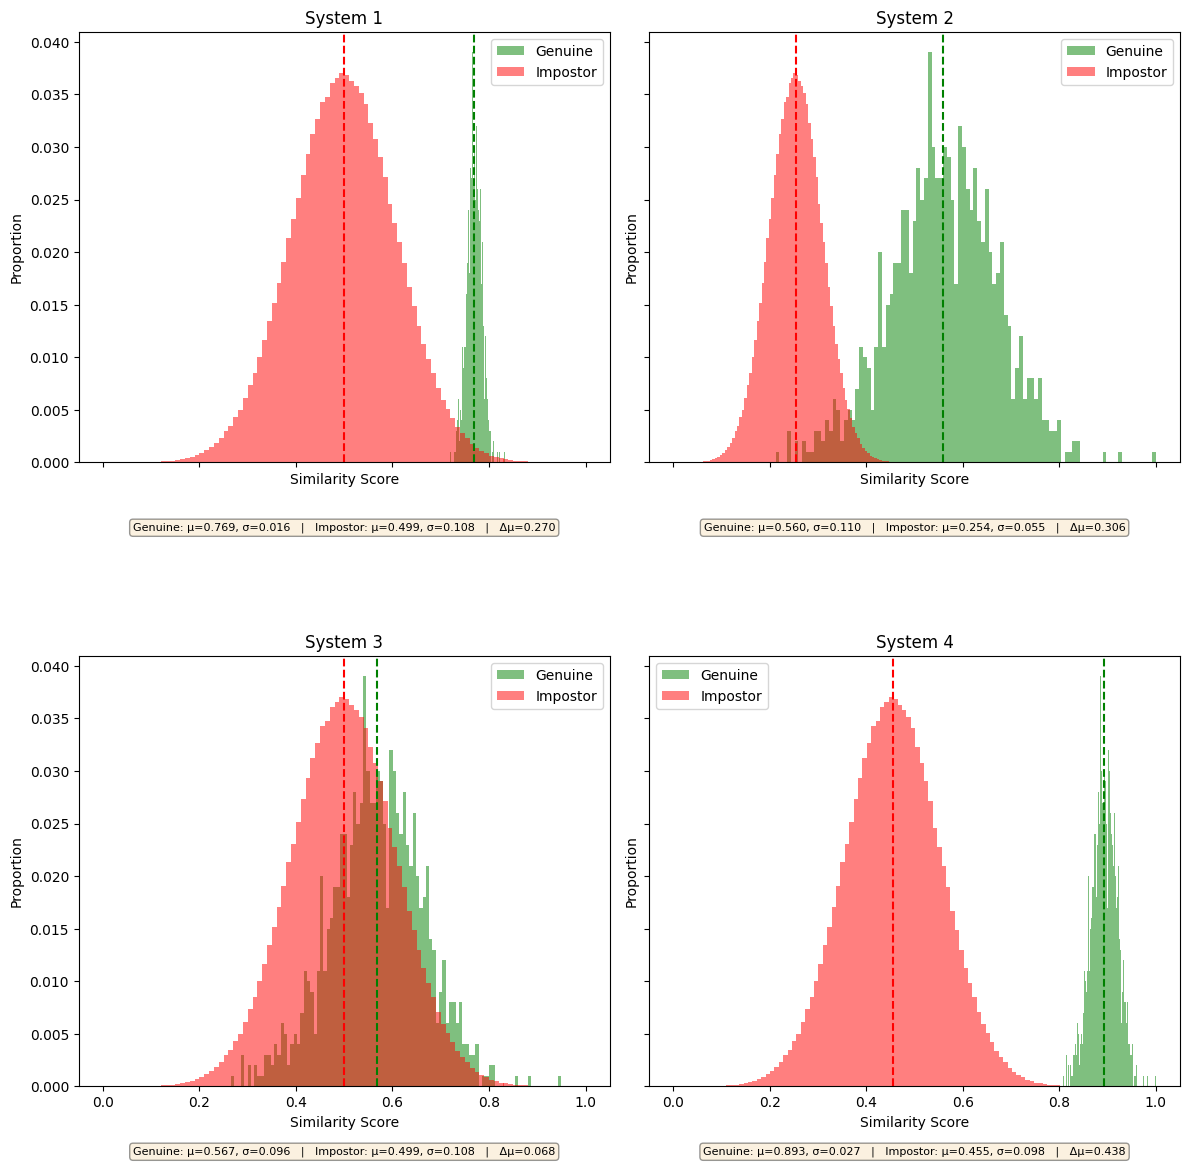

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharex=True, sharey=True)
axes = axes.flatten()

systems = [
    (system1_genuine_id, system1_scores, "System 1"),
    (system2_genuine_id, system2_scores, "System 2"),
    (system3_genuine_id, system3_scores, "System 3"),
    (system4_genuine_id, system4_scores, "System 4"),
]

for idx, (genuine_id, scores, name) in enumerate(systems):
    ax = axes[idx]
    
    genuine_scores = scores[genuine_id == 1]
    impostor_scores = scores[genuine_id == 0]
    
    # Use weights to normalize each histogram to proportions independently
    ax.hist(genuine_scores, bins=100, alpha=0.5, label="Genuine", color="green",
            weights=np.ones_like(genuine_scores) / len(genuine_scores))
    ax.hist(impostor_scores, bins=100, alpha=0.5, label="Impostor", color="red",
            weights=np.ones_like(impostor_scores) / len(impostor_scores))
    
    ax.axvline(genuine_scores.mean(), color="green", linestyle="--", linewidth=1.5)
    ax.axvline(impostor_scores.mean(), color="red", linestyle="--", linewidth=1.5)
    
    ax.set_title(name)
    ax.set_xlabel("Similarity Score")
    ax.set_ylabel("Proportion")
    ax.legend()
    
    stats_text = (
        f"Genuine: μ={genuine_scores.mean():.3f}, σ={genuine_scores.std():.3f}   |   "
        f"Impostor: μ={impostor_scores.mean():.3f}, σ={impostor_scores.std():.3f}   |   "
        f"Δμ={genuine_scores.mean() - impostor_scores.mean():.3f}"
    )
    ax.text(0.5, -0.14, stats_text, transform=ax.transAxes,
            fontsize=8, ha='center', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.subplots_adjust(hspace=0.45)
plt.show()

#### 2. FMR, FRR and Receiver Operating Characteristic (ROC) curve

The 'false accept' and 'false reject' regions in the illustration above are quantified using the False Match/Acceptance Rates (FMR/FAR) and False Non-Match/Rejections Rates (FNMR/FRR). The FMR and FNMR can easily be computed given the previously calculated probability distributions and a threshold value $\eta$. Practically this boils down to a counting problem, having $\mathcal{I}$ the indicator function (return 1 if x is true, else 0) we can compute:
$$
FMR(\eta) = p(s \geq \eta | I) \approx \frac{1}{|I|} \sum_{s \in I} \mathcal{I}(s \geq \eta),
$$
$$
FRR(\eta) = p(s < \eta | G) \approx \frac{1}{|G|} \sum_{s \in G} \mathcal{I}(s < \eta).
$$

We can also compute the Genuine Acceptance Rate (GAR)/True Match Rate (TMR) as:
$$
GAR(\eta) = p(s \geq \eta | G) = 1 - FRR(\eta).
$$

Note that choosing a threshold is always a tradeof between FMR and FNMR. <br>
<img src="img/FAR_FRR.png" width="300" height="auto" align="center"/>

To observe the impact of the threshold value, one often plots a [Receiver Operating Characteristic (ROC)](https://en.wikipedia.org/wiki/Receiver_operating_characteristic) curve. Usually in these curves the GAR/TMR is plotted against the FMR for different decision threshold values $\eta$. For those familiar with binary classification systems outside of the biometrics literature; the GAR/TMR is often referred to as the True Positive Rate (TPR), sensitivity or recall and FMR is also known as the False Positive Rate (FPR) or the False Accept Rate (FAR). 

<img src="img/ROC.png" width="700" height="auto" align="center"/>

<div class="alert alert-block alert-success">
<b>Q2: </b> ROC Curves
<ul>
    <li>Calculate FPR, TPR from the matching scores.</li>
    <li>Plot FAR and FRR as a function of the decision threshold.</li>
    <li>Plot the ROC curve for the four systems <b> in a single plot </b>. Plot for linear and logarithmic scale if needed. What do you observe?</li>
    <li>Plot the Detection Error Trade-off (DET) curve. How does it compare to ROC?</li>
</ul>  
</div>


<div class="alert alert-block alert-info">
<b>Tip:</b> 
We highly recommend you use the <a href="https://scikit-learn.org/stable/index.html">scikit-learn</a> package, it contains standard and advanced routines for machine learning, including classificaton and validation algorithms.
</div>

In [22]:
"""Calculate FPR, TPR from the matching scores."""
from sklearn.metrics import roc_curve

systems = [
    (system1_genuine_id, system1_scores, "System 1"),
    (system2_genuine_id, system2_scores, "System 2"),
    (system3_genuine_id, system3_scores, "System 3"),
    (system4_genuine_id, system4_scores, "System 4"),
]

roc_data = {}
for genuine_id, scores, name in systems:
    fpr, tpr, thresholds = roc_curve(genuine_id, scores)
    roc_data[name] = {"fpr": fpr, "tpr": tpr, "thresholds": thresholds}

    # Print a sample of values
    print(f"\n{name} — FPR, TPR at selected thresholds:")
    print(f"{'Threshold':>12} {'FPR (FAR)':>12} {'TPR (GAR)':>12} {'FRR':>12}")
    print("-" * 52)
    # Sample ~10 evenly spaced indices
    indices = np.linspace(0, len(thresholds) - 1, 10, dtype=int)
    for i in indices:
        print(f"{thresholds[i]:>12.4f} {fpr[i]:>12.6f} {tpr[i]:>12.6f} {1 - tpr[i]:>12.6f}")


System 1 — FPR, TPR at selected thresholds:
   Threshold    FPR (FAR)    TPR (GAR)          FRR
----------------------------------------------------
         inf     0.000000     0.000000     1.000000
      0.7885     0.003575     0.102000     0.898000
      0.7818     0.004304     0.214000     0.786000
      0.7767     0.004934     0.329000     0.671000
      0.7715     0.005665     0.443000     0.557000
      0.7667     0.006391     0.562000     0.438000
      0.7625     0.007149     0.677000     0.323000
      0.7570     0.008230     0.790000     0.210000
      0.7497     0.009961     0.899000     0.101000
      0.0000     1.000000     1.000000     0.000000

System 2 — FPR, TPR at selected thresholds:
   Threshold    FPR (FAR)    TPR (GAR)          FRR
----------------------------------------------------
         inf     0.000000     0.000000     1.000000
      0.4737     0.000031     0.792000     0.208000
      0.4576     0.000098     0.830000     0.170000
      0.4434     0.00028

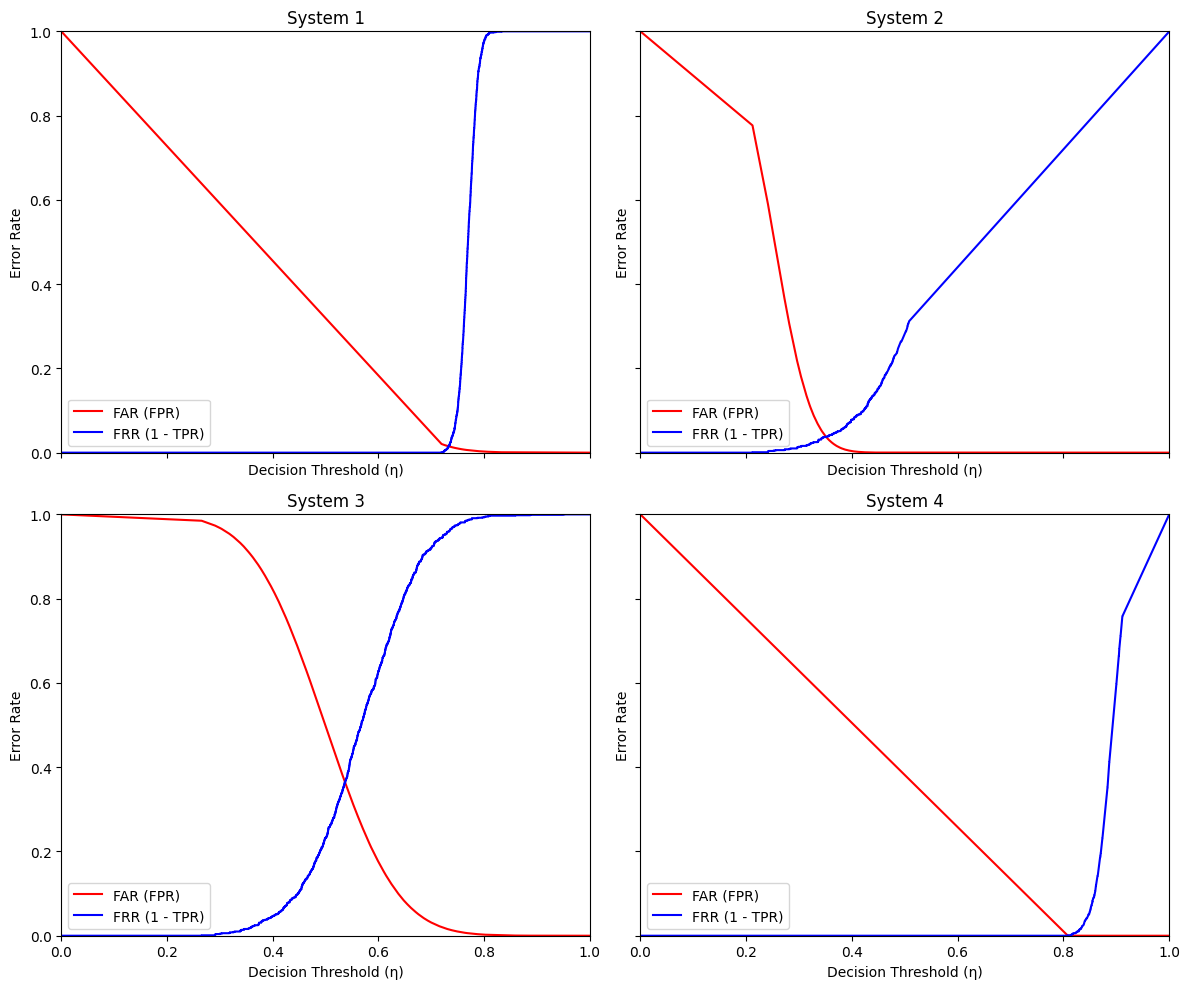

In [19]:
"""Plot FAR and FRR as a function of the decision threshold."""
# FAR <=> FPR
# FRR <=> FNR <=> FN/P <=> 1-TPR
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()

for idx, (name, data) in enumerate(roc_data.items()):
    ax = axes[idx]
    far = data["fpr"]
    frr = 1 - data["tpr"]
    thresholds = data["thresholds"]

    ax.plot(thresholds, far, color="red", label="FAR (FPR)")
    ax.plot(thresholds, frr, color="blue", label="FRR (1 - TPR)")

    ax.set_title(name)
    ax.set_xlabel("Decision Threshold (η)")
    ax.set_ylabel("Error Rate")
    ax.legend()
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

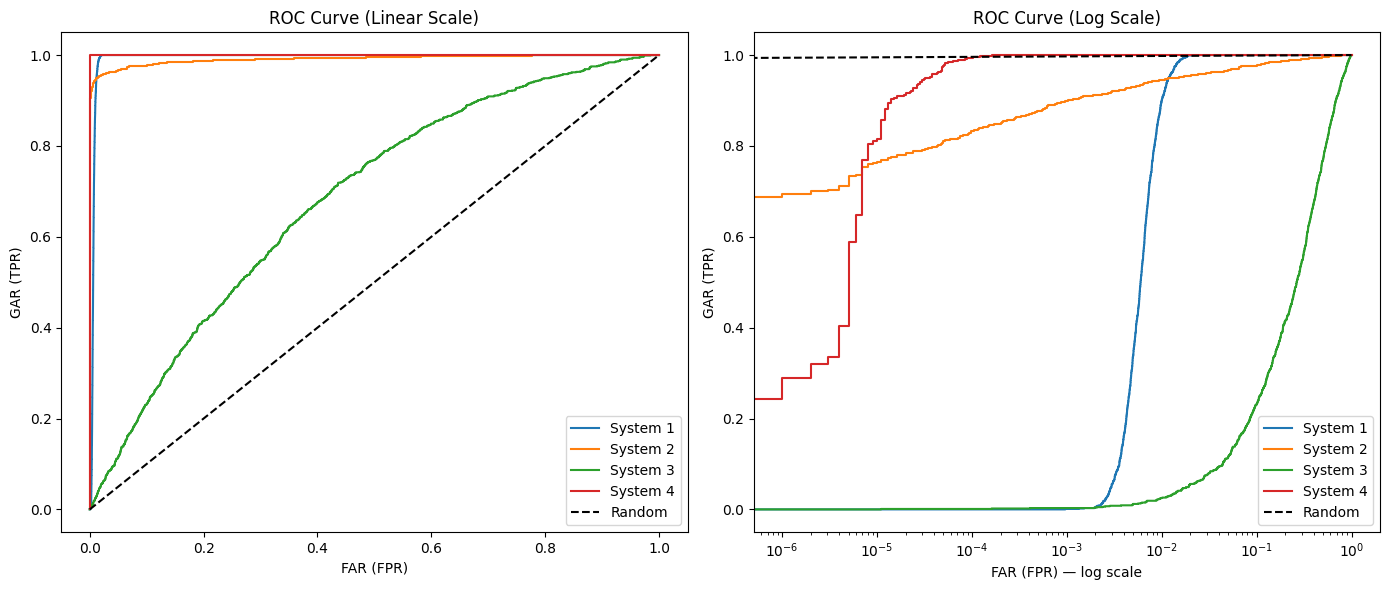

In [20]:
"""plot the ROC curve (TPR against the FPR for different threshold values)"""
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name, data in roc_data.items():
    axes[0].plot(data["fpr"], data["tpr"], label=name)
    axes[1].plot(data["fpr"], data["tpr"], label=name)

# Linear scale
axes[0].plot([0, 1], [0, 1], 'k--', label="Random")
axes[0].set_title("ROC Curve (Linear Scale)")
axes[0].set_xlabel("FAR (FPR)")
axes[0].set_ylabel("GAR (TPR)")
axes[0].legend()

# Log scale on x-axis
axes[1].set_xscale("log")
axes[1].plot([0, 1], [0, 1], 'k--', label="Random")
axes[1].set_title("ROC Curve (Log Scale)")
axes[1].set_xlabel("FAR (FPR) — log scale")
axes[1].set_ylabel("GAR (TPR)")
axes[1].legend()

plt.tight_layout()
plt.show()

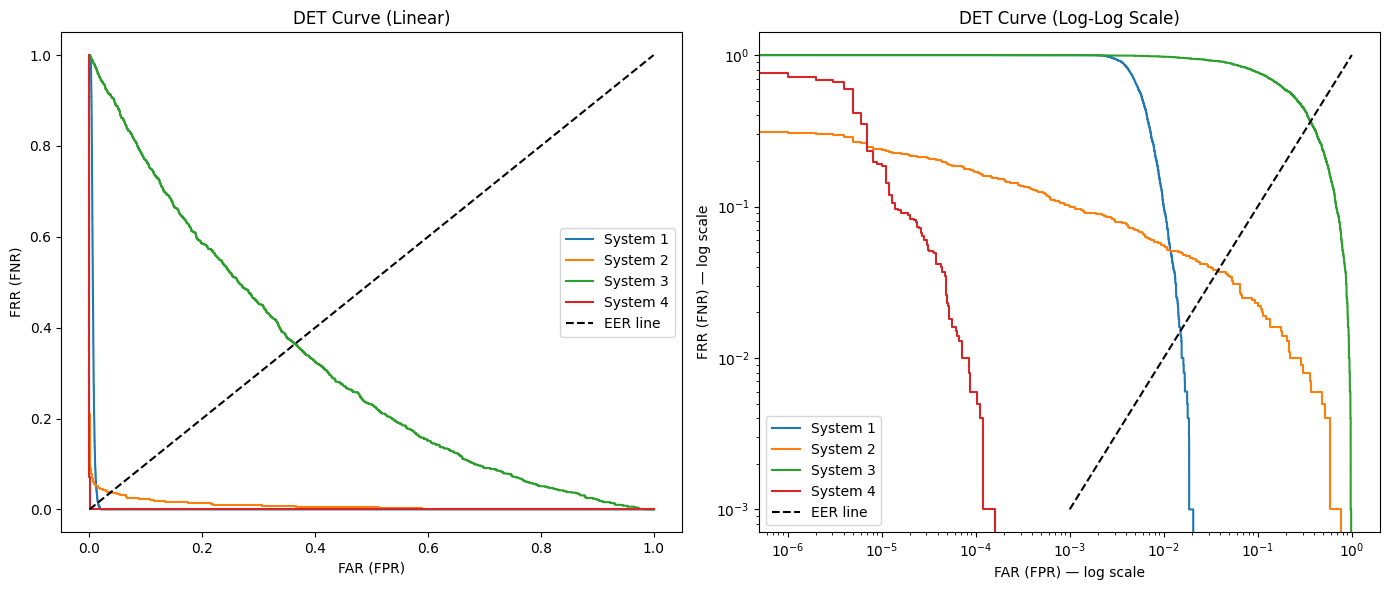

In [25]:
"""plot the DET curve (FRR (=1-tpr) against the FAR for different threshold values)"""

# FAR <=> FPR
# FRR <=> FNR <=> FN/P <=> 1-TPR
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name, data in roc_data.items():
    frr = 1 - data["tpr"]
    axes[0].plot(data["fpr"], frr, label=name)
    axes[1].plot(data["fpr"], frr, label=name)

# Linear
axes[0].plot([0, 1], [0, 1], 'k--', label="EER line")
axes[0].set_title("DET Curve (Linear)")
axes[0].set_xlabel("FAR (FPR)")
axes[0].set_ylabel("FRR (FNR)")
axes[0].legend()

# Log-log
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].plot([0.001, 1], [0.001, 1], 'k--', label="EER line")
axes[1].set_title("DET Curve (Log-Log Scale)")
axes[1].set_xlabel("FAR (FPR) — log scale")
axes[1].set_ylabel("FRR (FNR) — log scale")
axes[1].legend()

plt.tight_layout()
plt.show()

#### 3. F1 and accuracy as metrics

While biometric systems are, traditionally, evaluated using FMR and FRR and ROC/DET curves, we can also have a look at traditional [classification metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics) such as classification accuracy (or error) and F1 measure. 

<div class="alert alert-block alert-success">
<b>Q3: </b> Classification Metrics
<ul>
    <li>Plot F1 and accuracy as a function of the decision thresholds on the similarity score for the four systems<b> in a single plot </b>.</li>
    <li>Calculate the threshold and accuracy for which F1 is maximal. Is it an interesting operating point?</li>
    <li>Calculate the threshold and F1 for which accuracy is maximal. Is it an interesting operating point? Is there a difference with the results of the previous question and why?</li>
    <li>Is accuracy a good performance metric in this case?</li>
</ul>  
</div>

<div class="alert alert-block alert-info">
<b>Tip:</b> 
We highly recommend you use the <a href="https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics">scikit-learn classification metrics</a> to assist.
</div>


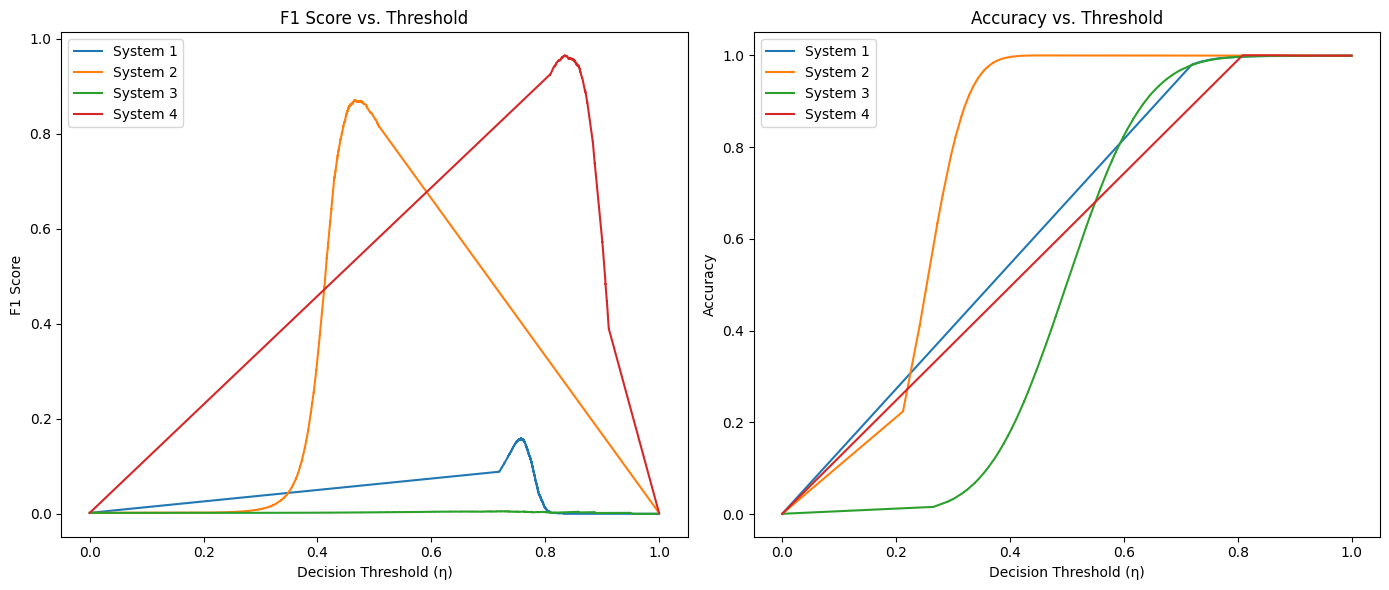

In [27]:
"""Plot F1 and accuracy as a function of the decision thresholds on the similarity score."""
# Hint: evaluating for ± 50 threshold values should suffice
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for genuine_id, scores, name in systems:
    fpr = roc_data[name]["fpr"]
    tpr = roc_data[name]["tpr"]
    thresholds = roc_data[name]["thresholds"]

    P = np.sum(genuine_id == 1)  # number of genuines
    N = np.sum(genuine_id == 0)  # number of impostors

    precision = (tpr * P) / (tpr * P + fpr * N + 1e-10)  # small epsilon to avoid /0
    recall = tpr
    f1 = 2 * precision * recall / (precision + recall + 1e-10)
    accuracy = (tpr * P + (1 - fpr) * N) / (P + N)

    axes[0].plot(thresholds, f1, label=name)
    axes[1].plot(thresholds, accuracy, label=name)

axes[0].set_title("F1 Score vs. Threshold")
axes[0].set_xlabel("Decision Threshold (η)")
axes[0].set_ylabel("F1 Score")
axes[0].legend()

axes[1].set_title("Accuracy vs. Threshold")
axes[1].set_xlabel("Decision Threshold (η)")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [28]:
"""Calculate the threshold for which F1 is maximal."""
print("=== Threshold where F1 is maximal ===")
print(f"{'System':>12} {'Threshold':>12} {'Max F1':>12} {'Accuracy':>12}")
print("-" * 52)

for genuine_id, scores, name in systems:
    fpr = roc_data[name]["fpr"]
    tpr = roc_data[name]["tpr"]
    thresholds = roc_data[name]["thresholds"]
    P = np.sum(genuine_id == 1)
    N = np.sum(genuine_id == 0)

    precision = (tpr * P) / (tpr * P + fpr * N + 1e-10)
    recall = tpr
    f1 = 2 * precision * recall / (precision + recall + 1e-10)
    accuracy = (tpr * P + (1 - fpr) * N) / (P + N)

    best_idx = np.argmax(f1)
    print(f"{name:>12} {thresholds[best_idx]:>12.4f} {f1[best_idx]:>12.4f} {accuracy[best_idx]:>12.4f}")


=== Threshold where F1 is maximal ===
      System    Threshold       Max F1     Accuracy
----------------------------------------------------
    System 1       0.7573       0.1586       0.9916
    System 2       0.4664       0.8714       0.9998
    System 3       0.7207       0.0053       0.9792
    System 4       0.8342       0.9656       0.9999


In [29]:
"""Do the same for the accuracy"""
print("\n=== Threshold where Accuracy is maximal ===")
print(f"{'System':>12} {'Threshold':>12} {'Max Accuracy':>12} {'F1':>12}")
print("-" * 52)

for genuine_id, scores, name in systems:
    fpr = roc_data[name]["fpr"]
    tpr = roc_data[name]["tpr"]
    thresholds = roc_data[name]["thresholds"]
    P = np.sum(genuine_id == 1)
    N = np.sum(genuine_id == 0)

    precision = (tpr * P) / (tpr * P + fpr * N + 1e-10)
    recall = tpr
    f1 = 2 * precision * recall / (precision + recall + 1e-10)
    accuracy = (tpr * P + (1 - fpr) * N) / (P + N)

    best_idx = np.argmax(accuracy)
    print(f"{name:>12} {thresholds[best_idx]:>12.4f} {accuracy[best_idx]:>12.4f} {f1[best_idx]:>12.4f}")


=== Threshold where Accuracy is maximal ===
      System    Threshold Max Accuracy           F1
----------------------------------------------------
    System 1          inf       0.9990       0.0000
    System 2       0.4772       0.9998       0.8692
    System 3          inf       0.9990       0.0000
    System 4       0.8342       0.9999       0.9656


#### 4. AUC and EER as summary measures

The overall performance (over all threshold settings) is typically expressed through:

* The Area Under the Curve (AUC) (with TPR((y-axis) vs FPR (x-axis))

<img src="img/AUC.png" width="250" height="auto"/>

The AUC can be used to compare different systems. The larger this number, the better.
However, since it is a summary measure, always inspect the full ROC curve to make decisions about performance given operating conditions (in wich FRR, FAR regime to work e.g.).

* The Equal Error Rate (EER), which is the point on the ROC-curve where FAR(FMR) equals FRR (1-TAR). A lower EER value indicates better performance. 

<img src="img/EER.png" width="300" height="300"/>

<div class="alert alert-block alert-success">
<b>Q4: </b> AUC, EER and alternatives
<ul>
    <li>Calculate ROC AUC. Is this a good metric? What does it reveal about the system? </li>
    <li>Calculate (by approximation) the EER and plot it on the FAR-FRR curve. Is this a good peration point?</li>
    <li>Calculate the decision threshold for which the sum of FRR and FAR is minimal. Is this point similar to the total classification error?</li> 
    <li>Discuss the importance of the FRR and the FAR if you want a very secure versus a very convenient system. </li> 
</ul>  
</div>


In [30]:
"""Calculate the ROC AUC."""
from sklearn.metrics import roc_auc_score

print(f"{'System':>12} {'AUC':>12}")
print("-" * 26)

for genuine_id, scores, name in systems:
    auc = roc_auc_score(genuine_id, scores)
    print(f"{name:>12} {auc:>12.4f}")

      System          AUC
--------------------------
    System 1       0.9935
    System 2       0.9916
    System 3       0.6833
    System 4       1.0000


System 1: EER = 0.0150 at threshold = 0.7327
System 2: EER = 0.0385 at threshold = 0.3503
System 3: EER = 0.3646 at threshold = 0.5365
System 4: EER = 0.0001 at threshold = 0.8086


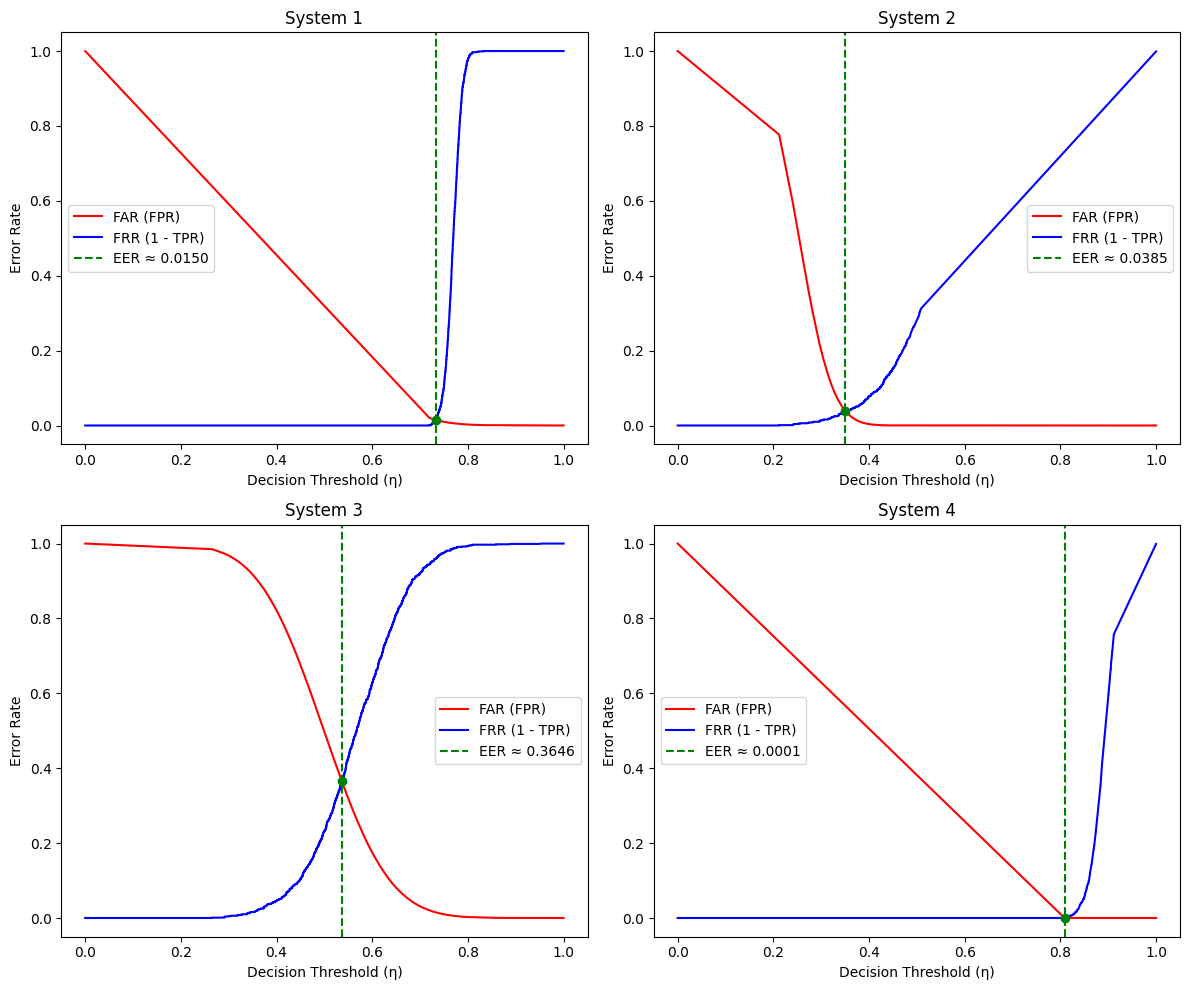

In [31]:
"""Calculate (by approximation) the EER and plot it on the FAR-FRR curve."""
# hints:
#  - avoid using a library that directly computes the EER for this assignment 
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (genuine_id, scores, name) in enumerate(systems):
    fpr, tpr, thresholds = roc_curve(genuine_id, scores)
    frr = 1 - tpr

    # Find EER by approximation
    eer_idx = np.argmin(np.abs(fpr - frr))
    eer = (fpr[eer_idx] + frr[eer_idx]) / 2
    eer_threshold = thresholds[eer_idx]

    print(f"{name}: EER = {eer:.4f} at threshold = {eer_threshold:.4f}")

    axes[idx].plot(thresholds, fpr, color='red', label='FAR (FPR)')
    axes[idx].plot(thresholds, frr, color='blue', label='FRR (1 - TPR)')
    axes[idx].axvline(eer_threshold, color='green', linestyle='--', label=f'EER ≈ {eer:.4f}')
    axes[idx].scatter([eer_threshold], [eer], color='green', zorder=5)
    axes[idx].set_title(name)
    axes[idx].set_xlabel("Decision Threshold (η)")
    axes[idx].set_ylabel("Error Rate")
    axes[idx].legend()

plt.tight_layout()
plt.show()

In [32]:
"""Calculate the decision threshold for which the sum of FRR and FAR is minimal."""
# hint: same as above
print(f"{'System':>12} {'Threshold':>12} {'FAR':>12} {'FRR':>12} {'FAR+FRR':>12}")
print("-" * 64)

for genuine_id, scores, name in systems:
    fpr, tpr, thresholds = roc_curve(genuine_id, scores)
    frr = 1 - tpr

    min_idx = np.argmin(fpr + frr)
    print(f"{name:>12} {thresholds[min_idx]:>12.4f} "
          f"{fpr[min_idx]:>12.4f} {frr[min_idx]:>12.4f} "
          f"{(fpr[min_idx] + frr[min_idx]):>12.4f}")

      System    Threshold          FAR          FRR      FAR+FRR
----------------------------------------------------------------
    System 1       0.7235       0.0186       0.0010       0.0196
    System 2       0.3778       0.0117       0.0510       0.0627
    System 3       0.5166       0.4362       0.2810       0.7172
    System 4       0.8086       0.0002       0.0000       0.0002


#### 5. Evaluation using Precision and Recall

[1]: <https://link.springer.com/book/10.1007/978-0-387-77326-1> ('Introduction to Biometrics' by AK Jain et al)
[2]: <https://machinelearningmastery.com/roc-curves-and-precision-recall-curves-for-classification-in-python/> (How and When to Use ROC Curves and Precision-Recall Curves for Classification in Python)
[3]: <https://en.wikipedia.org/w/index.php?title=Information_retrieval&oldid=793358396#Average_precision> (Average precision)

In a general binary classification setting, one also often presents Precision-Recall curves. PR-curves are sometimes summarized using the [average precision scores][3]. How and when to use ROC or PRC is discussed [here][2]. A more general discussion of these measures is provided [here](https://towardsdatascience.com/beyond-accuracy-precision-and-recall-3da06bea9f6c).  

Scikit-Learn provides routines for calculating these curves and numbers as demonstrated in the code below from this [link][2], it also provides an implementation of the [average precision scores](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html#sklearn.metrics.average_precision_score).


<div class="alert alert-block alert-success">

<b>Q5: </b> Precision-Recall curves and related summary measures
<ul>
    <li>Calculate and plot the Precision-Recall curve for these systems. What does it reveal about the performance of the systems?</li>
    <li>Does the ROC curve or the PRC curve make more sense to evaluate these four systems? (Tip: read the webpages mentioned above). </li>
    <li>Calculate the Area Under the PR-curve. Discuss.</li>
    <li>Calculate the average precision scores. Discuss its value.</li> 
</ul>  
</div>


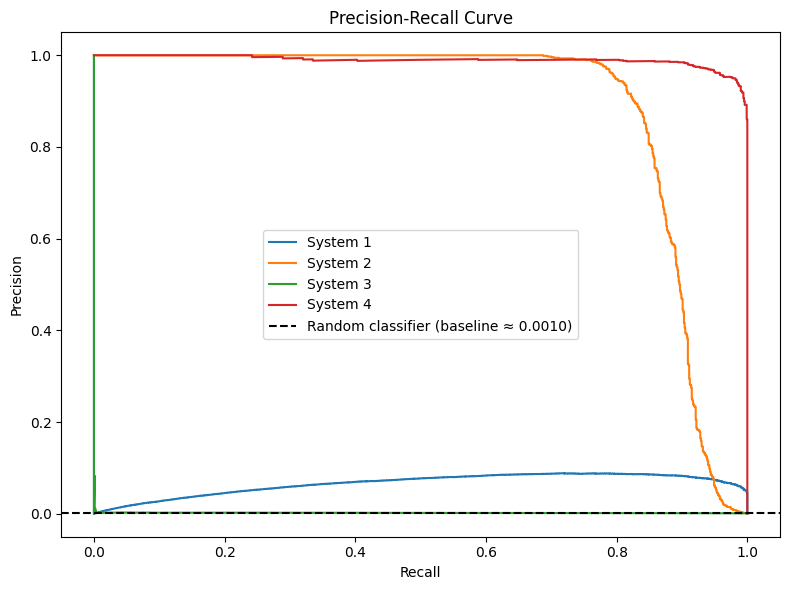

In [34]:
"""Calculate and plot the Precision-Recall curve for the systems"""
from sklearn.metrics import precision_recall_curve, auc, average_precision_score

fig, ax = plt.subplots(figsize=(8, 6))

for genuine_id, scores, name in systems:
    precision, recall, _ = precision_recall_curve(genuine_id, scores)
    "ax.plot(recall, precision, label=name)

baseline = np.sum(system1_genuine_id) / len(system1_genuine_id)
ax.axhline(y=baseline, color='black', linestyle='--', label=f'Random classifier (baseline ≈ {baseline:.4f})')

ax.set_title("Precision-Recall Curve")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
plt.tight_layout()
plt.show()

In [35]:
"""Calculate the Area Under the PR-curve."""
print(f"{'System':>12} {'AUC-PR':>12}")
print("-" * 26)

for genuine_id, scores, name in systems:
    precision, recall, _ = precision_recall_curve(genuine_id, scores)
    auc_pr = auc(recall, precision)
    print(f"{name:>12} {auc_pr:>12.4f}")

      System       AUC-PR
--------------------------
    System 1       0.0653
    System 2       0.8877
    System 3       0.0019
    System 4       0.9893


In [36]:
"""Calculate the average precision scores"""
print(f"{'System':>12} {'Avg Precision':>15}")
print("-" * 30)

for genuine_id, scores, name in systems:
    ap = average_precision_score(genuine_id, scores)
    print(f"{name:>12} {ap:>15.4f}")

      System   Avg Precision
------------------------------
    System 1          0.0654
    System 2          0.8877
    System 3          0.0020
    System 4          0.9893


## III. Validation of identification system 

### Evaluation using CMC curves
In an identification scenario one has a 1-to-many or multi-class classification problem. The performance of such a system is typically measured by the Cumulative Match Characteristic (CMC) curve. This curve plots the experimental probability that a correct identification is returned within the top-x (x=1, ..., N) ranked matching scores. 

<img src="img/CMC.jpg" width="500" height="auto"/>

[Bolle et al.](https://ieeexplore.ieee.org/document/1544394) show that:
> the CMC is also related to the FAR and FRR of a 1:1 matcher, i.e., the matcher that is used to rank the candidates by sorting the scores. This has as a consequence that when a 1:1 matcher is used for identification, that is, for sorting match scores from high to low, the CMC does not offer any additional information beyond the FAR and FRR curves. The CMC is just another way of displaying the data and can be computed from the FAR and FRR.

This paper is not mandatory but those interested can have a look at it.

CMC curves can easily be generated once you have the ranked matching scores for every test sample. In our example we can easily calculate it from the similarity matrix (note that in this very particular case we have only one genuine pair per test sample). 



<div class="alert alert-block alert-success">
<b>Q6: </b> CMC curves
<ul>
    <li>Calculate the Cumulative Matching Characteristic curve (implement this yourself)</li>
    <li>Compute the Rank-1 Recognition Rate.</li>
</ul>  
</div>


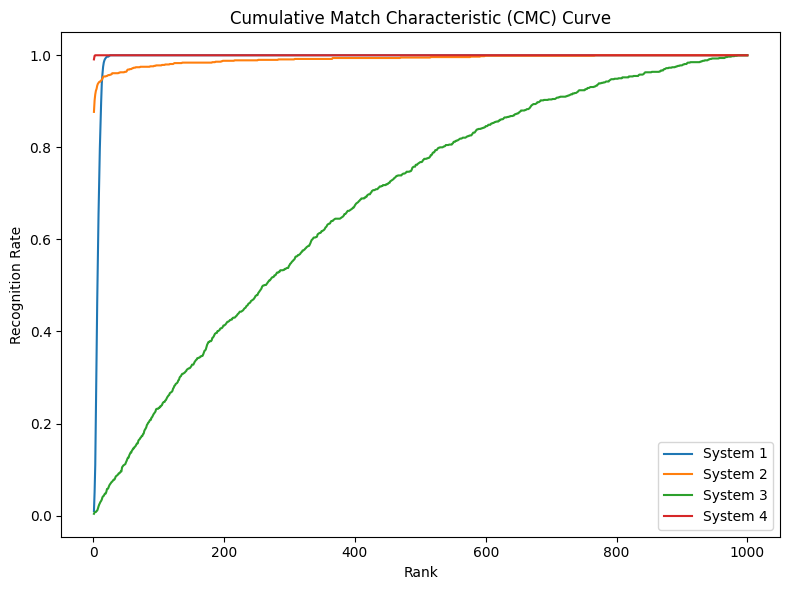

In [37]:
"""Calculate the Cumulative Matching Characteristic curve."""
# Hint: don't use a library
def compute_cmc(similarity_matrix):
    n = similarity_matrix.shape[0]
    ranks = np.zeros(n, dtype=int)
    
    for i in range(n):
        row = similarity_matrix[i]
        # rank all scores descending, find where the correct identity (diagonal) lands
        sorted_indices = np.argsort(row)[::-1]
        ranks[i] = np.where(sorted_indices == i)[0][0] + 1  # +1 because rank starts at 1
    
    # CMC[k] = fraction of probes where correct identity ranked <= k
    cmc = np.array([np.sum(ranks <= k) / n for k in range(1, n + 1)])
    return cmc

fig, ax = plt.subplots(figsize=(8, 6))

for sim_matrix, name in [(system1_similarity_matrix, "System 1"),
                          (system2_similarity_matrix, "System 2"),
                          (system3_similarity_matrix, "System 3"),
                          (system4_similarity_matrix, "System 4")]:
    cmc = compute_cmc(np.array(sim_matrix))
    ax.plot(range(1, len(cmc) + 1), cmc, label=name)

ax.set_title("Cumulative Match Characteristic (CMC) Curve")
ax.set_xlabel("Rank")
ax.set_ylabel("Recognition Rate")
ax.legend()
plt.tight_layout()
plt.show()

In [38]:
"""compute the Rank-1 Recognition Rate."""
print(f"{'System':>12} {'Rank-1 Rate':>12}")
print("-" * 26)

for sim_matrix, name in [(system1_similarity_matrix, "System 1"),
                          (system2_similarity_matrix, "System 2"),
                          (system3_similarity_matrix, "System 3"),
                          (system4_similarity_matrix, "System 4")]:
    cmc = compute_cmc(np.array(sim_matrix))
    print(f"{name:>12} {cmc[0]:>12.4f}")

      System  Rank-1 Rate
--------------------------
    System 1       0.0100
    System 2       0.8770
    System 3       0.0040
    System 4       0.9910


<div class="alert alert-block alert-success">
<b>Q7: </b> Evaluate different biometric systems
<ul>
    <li>Propose a new metric not mentioned in this task to evaluate these four systems. This can be something you come up with yourself by adjusting/combining some of the existing metrics in this task or something you find online. Explain in what way your new method is more/less suited to evaluate these systems </li>
</ul>  
</div>

## IV. Assignment Instructions

For the submission deadlines consult the slides in the “practical info module” on Toledo.

For the guidelines and submission instructions consult "Assignments/Guidelines/" on Toledo.

